In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras.src.trainers.data_adapters.py_dataset_adapter")


In [3]:
from sklearn.utils import class_weight


In [4]:
import os

# Update this path to match your extracted folder location
base_dir = r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset"

# Check if the path exists
if os.path.exists(base_dir):
    print("✅ Dataset path is valid.")
else:
    print("❌ Path not found. Double-check the folder location.")

✅ Dataset path is valid.


In [5]:
class_counts = {cls: len(os.listdir(os.path.join(base_dir, cls)))
                for cls in os.listdir(base_dir)
                if os.path.isdir(os.path.join(base_dir, cls))}
print("Class distribution:", class_counts)


Class distribution: {'0': 62, '1': 113, '2': 69, '3': 94, '4': 94, '5': 90, '6': 72, '7': 90, '8': 81, '9': 95, 'a': 3758, 'b': 3369, 'c': 2310, 'd': 4968, 'e': 3961, 'f': 5055, 'g': 5290, 'h': 5203, 'i': 4916, 'j': 2658, 'k': 5414, 'l': 5524, 'm': 1887, 'n': 2281, 'o': 3947, 'p': 3620, 'q': 3726, 'r': 5272, 's': 4425, 't': 2202, 'u': 4406, 'v': 5116, 'w': 3769, 'x': 4500, 'y': 4524, 'z': 2459}


In [6]:
import os

base_dir = r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset"# Update if needed
image_extensions = ('.jpg', '.jpeg', '.png')

total_images = 0
class_image_counts = {}

for cls in os.listdir(base_dir):
    cls_path = os.path.join(base_dir, cls)
    if os.path.isdir(cls_path):
        count = sum(1 for file in os.listdir(cls_path) if file.lower().endswith(image_extensions))
        class_image_counts[cls] = count
        total_images += count

print("🧾 Class-wise image counts:")
for cls, count in class_image_counts.items():
    print(f"  {cls}: {count} images")

print(f"\n📦 Total images in dataset: {total_images}")



🧾 Class-wise image counts:
  0: 62 images
  1: 113 images
  2: 69 images
  3: 94 images
  4: 94 images
  5: 90 images
  6: 72 images
  7: 90 images
  8: 81 images
  9: 95 images
  a: 3758 images
  b: 3369 images
  c: 2310 images
  d: 4968 images
  e: 3961 images
  f: 5055 images
  g: 5290 images
  h: 5203 images
  i: 4916 images
  j: 2658 images
  k: 5414 images
  l: 5524 images
  m: 1887 images
  n: 2281 images
  o: 3947 images
  p: 3620 images
  q: 3726 images
  r: 5272 images
  s: 4425 images
  t: 2202 images
  u: 4406 images
  v: 5116 images
  w: 3769 images
  x: 4500 images
  y: 4524 images
  z: 2459 images

📦 Total images in dataset: 105420


In [7]:
import os
import json
import numpy as np
import cv2
import mediapipe as mp
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.utils import class_weight


In [8]:
base_dir = r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset"
img_size = (128, 128)
batch_size = 32

def check_class_distribution(base_dir):
    class_counts = {cls: len(os.listdir(os.path.join(base_dir, cls))) for cls in os.listdir(base_dir)}
    print("Class distribution:", class_counts)
    return class_counts

check_class_distribution(base_dir)


Class distribution: {'0': 62, '1': 113, '2': 69, '3': 94, '4': 94, '5': 90, '6': 72, '7': 90, '8': 81, '9': 95, 'a': 3758, 'b': 3369, 'c': 2310, 'd': 4968, 'e': 3961, 'f': 5055, 'g': 5290, 'h': 5203, 'i': 4916, 'j': 2658, 'k': 5414, 'l': 5524, 'm': 1887, 'n': 2281, 'o': 3947, 'p': 3620, 'q': 3726, 'r': 5272, 's': 4425, 't': 2202, 'u': 4406, 'v': 5116, 'w': 3769, 'x': 4500, 'y': 4524, 'z': 2459}


{'0': 62,
 '1': 113,
 '2': 69,
 '3': 94,
 '4': 94,
 '5': 90,
 '6': 72,
 '7': 90,
 '8': 81,
 '9': 95,
 'a': 3758,
 'b': 3369,
 'c': 2310,
 'd': 4968,
 'e': 3961,
 'f': 5055,
 'g': 5290,
 'h': 5203,
 'i': 4916,
 'j': 2658,
 'k': 5414,
 'l': 5524,
 'm': 1887,
 'n': 2281,
 'o': 3947,
 'p': 3620,
 'q': 3726,
 'r': 5272,
 's': 4425,
 't': 2202,
 'u': 4406,
 'v': 5116,
 'w': 3769,
 'x': 4500,
 'y': 4524,
 'z': 2459}

In [9]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    shear_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

val_generator = val_datagen.flow_from_directory(
    base_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

# Save class indices
class_indices = train_generator.class_indices
with open("class_indices.json", "w") as f:
    json.dump(class_indices, f)
print("Class indices:", class_indices)


Found 84350 images belonging to 36 classes.
Found 21070 images belonging to 36 classes.
Class indices: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'b': 11, 'c': 12, 'd': 13, 'e': 14, 'f': 15, 'g': 16, 'h': 17, 'i': 18, 'j': 19, 'k': 20, 'l': 21, 'm': 22, 'n': 23, 'o': 24, 'p': 25, 'q': 26, 'r': 27, 's': 28, 't': 29, 'u': 30, 'v': 31, 'w': 32, 'x': 33, 'y': 34, 'z': 35}


In [10]:
def create_model(input_shape, num_classes):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=output_layer)
    model.compile(optimizer=keras.optimizers.Adam(1e-4),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

num_classes = len(train_generator.class_indices)
model = create_model((img_size[0], img_size[1], 3), num_classes)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 Conv1 (Conv2D)              (None, 64, 64, 32)           864       ['input_2[0][0]']             
                                                                                                  
 bn_Conv1 (BatchNormalizati  (None, 64, 64, 32)           128       ['Conv1[0][0]']               
 on)                                                                                              
                                                                                                  
 Conv1_relu (ReLU)           (None, 64, 64, 32)           0         ['bn_Conv1[0][0]']        

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build CNN model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(train_generator.num_classes, activation='softmax')  # output layer
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 62, 62, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 31, 31, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 29, 29, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 14, 14, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       73856     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 128)         0

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight
import numpy as np

# ✅ Data augmentation and rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2  # 80% train / 20% validation
)

# ✅ Training generator
train_generator = train_datagen.flow_from_directory(
    r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset",
    target_size=(224, 224),   # 👈 keep consistent with model input
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# ✅ Validation generator
val_generator = train_datagen.flow_from_directory(
    r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset",
    target_size=(224, 224),   # 👈 same as training
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# ✅ Compute class weights (to handle imbalance)
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)
print("Number of classes:", train_generator.num_classes)

Found 84350 images belonging to 36 classes.
Found 21070 images belonging to 36 classes.
Class Weights: {0: 46.861111111111114, 1: 25.747863247863247, 2: 41.84027777777778, 3: 30.829678362573098, 4: 30.829678362573098, 5: 32.54243827160494, 6: 40.39750957854406, 7: 32.54243827160494, 8: 36.047008547008545, 9: 30.829678362573098, 10: 0.779200384288512, 11: 0.8690858885591823, 12: 1.2678872053872055, 13: 0.5894479385045422, 14: 0.7393674836085691, 15: 0.5793905923727882, 16: 0.5536520688930897, 17: 0.562828622521152, 18: 0.5957425770545527, 19: 1.1015776001671629, 20: 0.5408715502205806, 21: 0.5301030668677728, 22: 1.551692420897719, 23: 1.2838660578386605, 24: 0.7419428611638871, 25: 0.809066144874156, 26: 0.7859964963285997, 27: 0.5554897002265423, 28: 0.6618801004394225, 29: 1.3297704628578635, 30: 0.6646966115051222, 31: 0.5724543258137199, 32: 0.7768751842027705, 33: 0.6508487654320988, 34: 0.6472529158993248, 35: 1.190577009936766}
Number of classes: 36


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 📌 1. Define base model
base_model = MobileNetV2(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # freeze base initially

# 📌 2. Build final model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")  # num_classes = your ASL categories
])

# 📌 3. Compile (Phase 1)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# 📌 4. Callbacks (no checkpoints here)
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, verbose=1)
]

# 📌 5. Train Phase 1 (frozen base model)
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# 📌 6. Fine-tune Phase 2 (unfreeze last 80 layers)
base_model.trainable = True
for layer in base_model.layers[:-80]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# 📌 7. Evaluate
loss, acc = model.evaluate(val_generator)
print(f"✅ Final Validation Accuracy: {acc*100:.2f}%")


Epoch 1/20
2636/2636 [==============================] - 3742s 1s/step - loss: 2.2871 - accuracy: 0.4347 - val_loss: 1.6023 - val_accuracy: 0.7129 - lr: 0.0010
Epoch 2/20
2636/2636 [==============================] - 3560s 1s/step - loss: 1.8444 - accuracy: 0.5696 - val_loss: 1.6104 - val_accuracy: 0.6945 - lr: 0.0010
Epoch 3/20
2636/2636 [==============================] - 4184s 2s/step - loss: 1.7868 - accuracy: 0.5971 - val_loss: 1.5016 - val_accuracy: 0.7396 - lr: 0.0010
Epoch 4/20
2636/2636 [==============================] - 4654s 2s/step - loss: 1.7333 - accuracy: 0.6201 - val_loss: 1.4508 - val_accuracy: 0.7614 - lr: 0.0010
Epoch 5/20
2636/2636 [==============================] - 3764s 1s/step - loss: 1.6839 - accuracy: 0.6384 - val_loss: 1.4233 - val_accuracy: 0.7701 - lr: 0.0010
Epoch 6/20
2636/2636 [==============================] - 3617s 1s/step - loss: 1.6604 - accuracy: 0.6463 - val_loss: 1.5033 - val_accuracy: 0.7497 - lr: 0.0010
Epoch 7/20
2636/2636 [========================

In [17]:
# 📌 8. Save final trained model
   # old HDF5 format (works but legacy)
model.save("asl_final_model.keras")  # ✅ recommended new format

# Also save the class labels (for webcam later)
import json
with open("class_indices.json", "w") as f:
    json.dump(train_generator.class_indices, f)


In [18]:
# Save epochs actually run
epochs_run_phase1 = len(history.history['loss'])
epochs_run_phase2 = len(history_finetune.history['loss'])

print(f"📌 Phase 1 ran for {epochs_run_phase1} epochs")
print(f"📌 Phase 2 ran for {epochs_run_phase2} epochs")

with open("asl_epochs_run.txt", "w") as f:
    f.write(f"Phase 1 epochs: {epochs_run_phase1}\n")
    f.write(f"Phase 2 epochs: {epochs_run_phase2}\n")


📌 Phase 1 ran for 20 epochs
📌 Phase 2 ran for 30 epochs


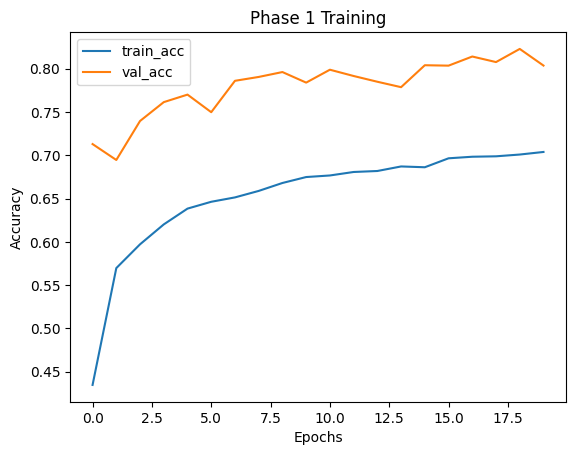

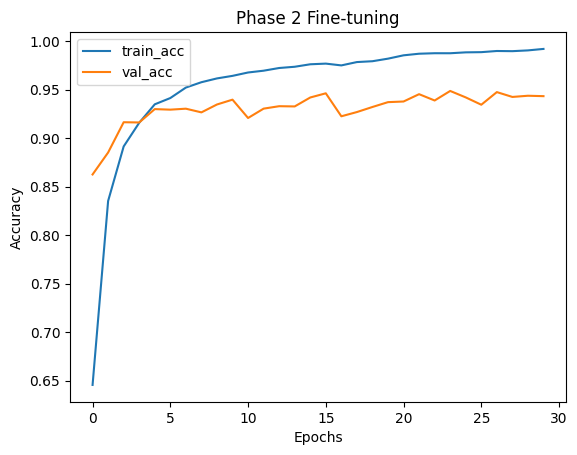

In [19]:
import matplotlib.pyplot as plt

def plot_training(history, title):
    plt.plot(history.history['accuracy'], label='train_acc')
    plt.plot(history.history['val_accuracy'], label='val_acc')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

plot_training(history, "Phase 1 Training")
plot_training(history_finetune, "Phase 2 Fine-tuning")


In [24]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = r"C:\Users\Anushree S\Downloads\archive (7)\processed_combine_asl_dataset\8\hand1_8_left_seg_3_cropped.png" # 👈 replace with your image path
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0) / 255.0

pred = model.predict(x)
predicted_class = np.argmax(pred, axis=1)[0]

print(f"Predicted ASL Sign: {predicted_class}")


1/1 [==============================] - 0s 70ms/step
Predicted ASL Sign: 8


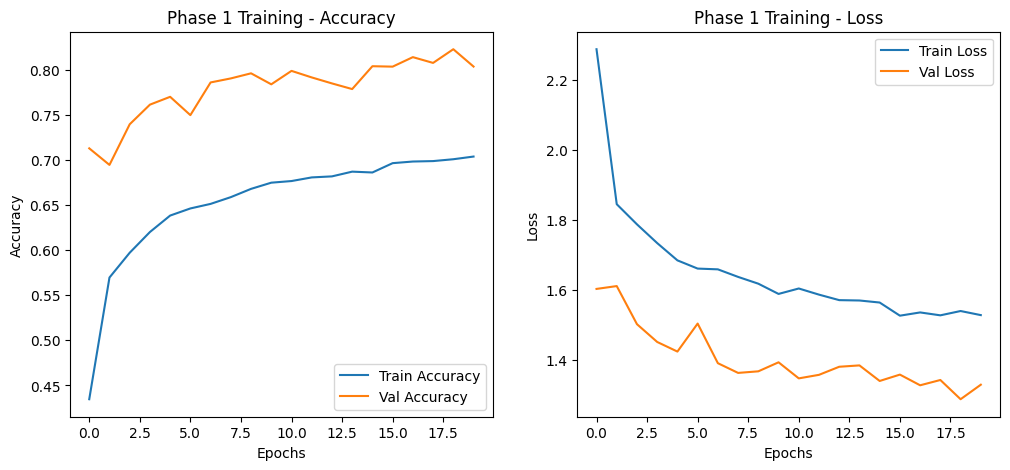

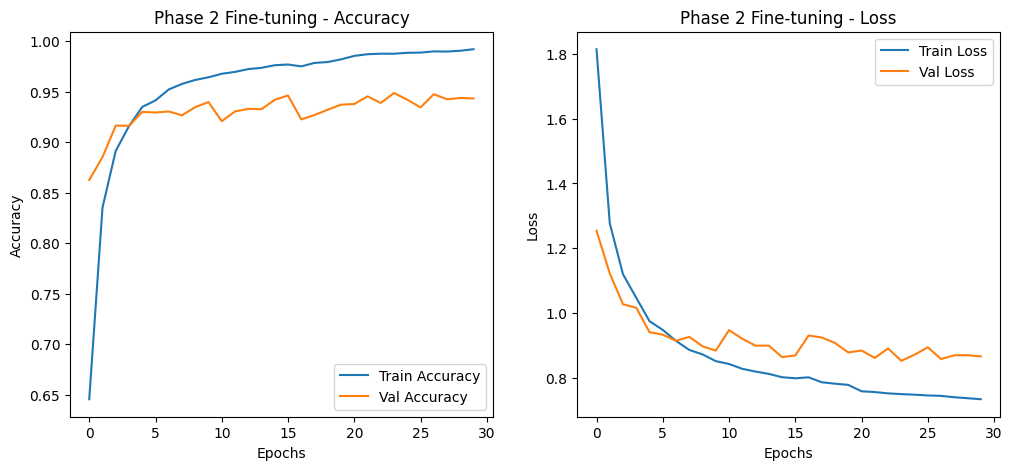

In [25]:
import matplotlib.pyplot as plt

def plot_curves(history, title):
    # Plot Accuracy
    plt.figure(figsize=(12,5))
    
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plot Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()

# 📌 Plot Phase 1 training curves
plot_curves(history, "Phase 1 Training")

# 📌 Plot Phase 2 fine-tuning curves
plot_curves(history_finetune, "Phase 2 Fine-tuning")


In [26]:
import pickle

# Save both histories
with open("asl_training_history.pkl", "wb") as f:
    pickle.dump({"phase1": history.history, "phase2": history_finetune.history}, f)


In [27]:
loss, acc = model.evaluate(val_generator)
print(f"📊 Final Validation Accuracy: {acc*100:.2f}%")


659/659 [==============================] - 1381s 2s/step - loss: 0.8627 - accuracy: 0.9452
📊 Final Validation Accuracy: 94.52%


In [7]:
model.save("asl_final_model.keras")
print("Model saved successfully!")

NameError: name 'model' is not defined

In [6]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_labels, yticklabels=class_labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


NameError: name 'y_true' is not defined

In [6]:
import cv2
import numpy as np
import json
from tensorflow.keras.models import load_model

# ✅ Load saved model
model = load_model("asl_final_model.keras")
print("✅ Model loaded successfully!")

# ✅ Load class labels (keys: class names, values: numeric indices)
with open("class_indices.json", "r") as f:
    class_indices = json.load(f)

# Reverse dictionary to map index → label
labels = {v: k for k, v in class_indices.items()}
print("🧩 Loaded Labels:", labels)

# ✅ Initialize webcam
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("❌ Error: Could not open webcam.")
    cap.release()
    cv2.destroyAllWindows()
    raise SystemExit()

print("🎥 Webcam started — press 'q' to quit.")

while True:
    ret, frame = cap.read()
    if not ret:
        print("⚠️ Frame capture failed.")
        break

    # Flip horizontally for a mirror effect
    frame = cv2.flip(frame, 1)

    # Define ROI (manually adjustable)
    x, y, w, h = 100, 100, 300, 300
    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
    roi = frame[y:y+h, x:x+w]

    # ✅ Preprocess ROI for model
    img = cv2.resize(roi, (224, 224))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # ✅ Predict class
    preds = model.predict(img)
    pred_class = np.argmax(preds)
    pred_label = labels[pred_class]
    confidence = np.max(preds)

    # ✅ Display prediction on video
    text = f"{pred_label} ({confidence*100:.1f}%)"
    cv2.putText(frame, text, (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Show video feed
    cv2.imshow("ASL Live Prediction", frame)

    # Quit on 'q'
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# ✅ Cleanup
cap.release()
cv2.destroyAllWindows()
print("👋 Webcam closed.")


✅ Model loaded successfully!
🧩 Loaded Labels: {0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'a', 11: 'b', 12: 'c', 13: 'd', 14: 'e', 15: 'f', 16: 'g', 17: 'h', 18: 'i', 19: 'j', 20: 'k', 21: 'l', 22: 'm', 23: 'n', 24: 'o', 25: 'p', 26: 'q', 27: 'r', 28: 's', 29: 't', 30: 'u', 31: 'v', 32: 'w', 33: 'x', 34: 'y', 35: 'z'}
🎥 Webcam started — press 'q' to quit.
1/1 [==============================] - 0s 69ms/step
👋 Webcam closed.
